# **Predicción de parto exitoso de una hembra porcina (Clasificación)**

### **Por:**

*   Yasmin Judith Florez Zabala
*   John Jairo Sevilla Rodriguez
*   Yulexa Andrea Aragón Lemus

### **Ciclo de vida**
1. Preparación de Datos
2. Validación Cruzada de los datos
3. Aprendizaje y Evaluación del Modelo: Precisión y F1-score
4. Guardar el Modelo

In [2]:
# Se importan las librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

## **1. Preparación de Datos**

In [3]:
# Se importa la librería para leer archivos .arff
from scipy.io import arff

# Se lee el archivo ARFF
data, meta = arff.loadarff('sabana_hembras_porcinas_procesado.arff')

# Se convierte a DataFrame
df = pd.DataFrame(data)

# Se decodifica todas las columnas de tipo objeto
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# Se muestran las 5 primeras filas
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO
0,6.0,14.000,2.0,0.0,EXITOSO
1,7.0,14.000,5.0,0.0,NO_EXITOSO
2,8.0,13.750,6.0,0.0,EXITOSO
3,9.0,14.000,6.0,0.0,NO_EXITOSO
4,10.0,13.666,6.0,0.0,EXITOSO


In [ ]:
# Se conocen los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NUMERO_PARTO               350981 non-null  float64
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64
 3   RETORNOS_ACUMULADOS        350981 non-null  float64
 4   PARTO_EXITOSO              350981 non-null  object 
dtypes: float64(4), object(1)
memory usage: 13.4+ MB


In [ ]:
# Se corrigen los tipos de datos
df["PARTO_EXITOSO"] = df["PARTO_EXITOSO"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   NUMERO_PARTO               350981 non-null  float64 
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64 
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64 
 3   RETORNOS_ACUMULADOS        350981 non-null  float64 
 4   PARTO_EXITOSO              350981 non-null  category
dtypes: category(1), float64(4)
memory usage: 11.0 MB


In [ ]:
# Descripción de los datos
df.describe()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
count,350981.000000,350981.000000,350981.000000,350981.000000
mean,4.562569,13.526068,2.135694,0.135620
std,2.354193,2.920242,2.644555,0.417706
min,2.000000,0.000000,0.000000,0.000000
25%,3.000000,12.000000,0.000000,0.000000
50%,4.000000,13.800000,1.000000,0.000000
75%,6.000000,15.500000,3.000000,0.000000
max,19.000000,31.000000,35.000000,9.000000


<Axes: >

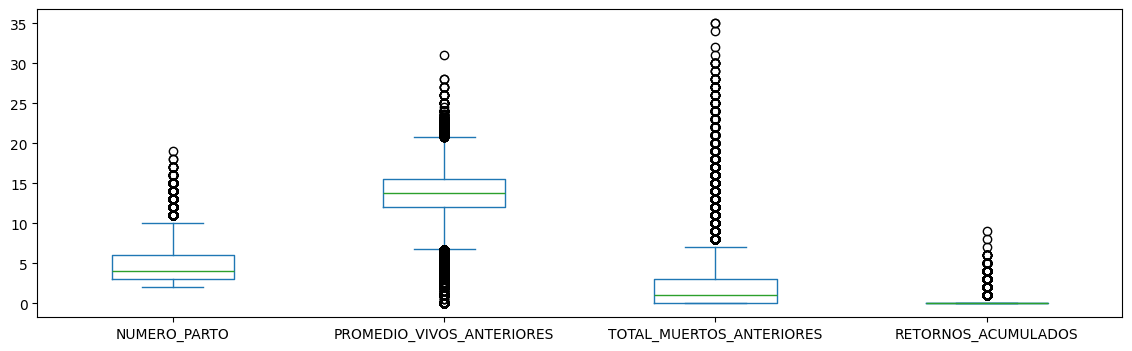

In [ ]:
# Descripción de las variables numéricas
df.plot(kind='box', figsize=(14, 4))

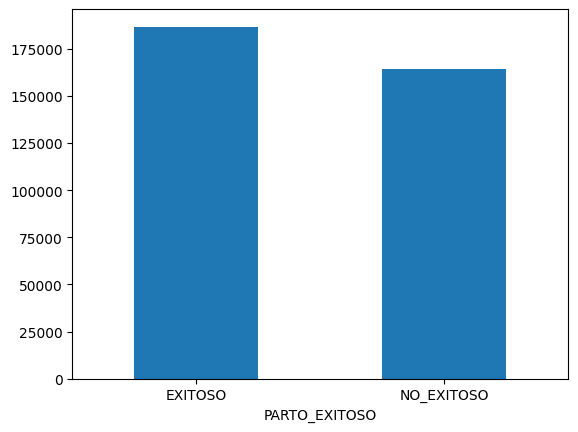

In [ ]:
# Descripción de la variable objetivo
df['PARTO_EXITOSO'].value_counts().plot(kind='bar')
plt.xticks(rotation=360)
plt.show()

In [ ]:
# Instalación de pandas profiling
!pip install ydata-profiling

In [ ]:
from pandas_profiling import ProfileReport
profile_data = ProfileReport(df, minimal=False)
profile_data

/tmp/ipykernel_12683/214452836.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00,  7.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
# Configuración de variables
objetivo = "PARTO_EXITOSO"
predictoras_numericas = ["NUMERO_PARTO", "PROMEDIO_VIVOS_ANTERIORES",	"TOTAL_MUERTOS_ANTERIORES",	"RETORNOS_ACUMULADOS"]

In [5]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df[objetivo] = labelencoder.fit_transform(df[objetivo])
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO
0,6.0,14.000,2.0,0.0,0
1,7.0,14.000,5.0,0.0,1
2,8.0,13.750,6.0,0.0,0
3,9.0,14.000,6.0,0.0,1
4,10.0,13.666,6.0,0.0,0


## **2. Validación Cruzada de los datos**

In [6]:
# Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

# Dataframe para comparar los modelos
comparacion_CV = pd.DataFrame()
scoring = ('f1', 'accuracy', 'precision', 'recall')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [7]:
# Se separa variables predictoras y objetivo
X = df.drop(objetivo, axis=1)
Y = df[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 4 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NUMERO_PARTO               350981 non-null  float64
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64
 3   RETORNOS_ACUMULADOS        350981 non-null  float64
dtypes: float64(4)
memory usage: 10.7 MB


## **3. Aprendizaje y Evaluación del Modelo**

### **3.1. Árbol de Clasificación**

In [ ]:
# Se importa el módulo de árboles de decisión desde sklearn
from sklearn import tree

# Se crea el modelo de clasificación tipo Árbol de Decisión
# criterion='gini' -> utiliza el índice Gini para medir la pureza de las divisiones
# min_samples_leaf=30 -> cada hoja debe tener mínimo 30 registros para evitar sobreajuste
# max_depth=7 -> limita la profundidad máxima del árbol para controlar su complejidad
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=30, max_depth=7)

# Se evalúa el modelo mediante validación cruzada
# X -> variables predictoras
# Y -> variable objetivo
# cv=cv -> número de particiones (folds) definidas previamente
# scoring=scoring -> métricas de evaluación seleccionadas
# return_train_score=True -> devuelve métricas tanto de entrenamiento como de prueba
# return_estimator=False -> no guarda los modelos entrenados de cada fold
scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)

# Resultados
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall
0,0.288193,0.021742,0.565757,0.566558,0.623522,0.623961,0.614945,0.615307,0.523856,0.524966
1,0.265728,0.020134,0.559815,0.565404,0.620491,0.624041,0.612481,0.616133,0.515489,0.522393
2,0.271244,0.019843,0.570912,0.571613,0.621403,0.623316,0.608103,0.611232,0.538007,0.536817
3,0.264280,0.020888,0.559127,0.559774,0.622486,0.623342,0.616751,0.618070,0.511350,0.511526
4,0.263719,0.028930,0.549776,0.555179,0.620007,0.623550,0.617268,0.621253,0.495588,0.501809
5,0.271911,0.020418,0.550142,0.555493,0.620662,0.623395,0.618382,0.620745,0.495466,0.502654
6,0.275051,0.020375,0.567529,0.569782,0.621745,0.623531,0.610570,0.612656,0.530156,0.532516
7,0.312144,0.021706,0.555117,0.553782,0.624110,0.623095,0.622429,0.621171,0.500943,0.499584
8,0.273811,0.020834,0.575543,0.571296,0.624594,0.623038,0.611389,0.610893,0.543667,0.536519
9,0.271533,0.029510,0.579598,0.576521,0.625078,0.622477,0.610061,0.607038,0.552033,0.548925


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.275761
score_time,0.022438
test_f1,0.563332
train_f1,0.564540
test_accuracy,0.622410
train_accuracy,0.623375
test_precision,0.614238
train_precision,0.615450
test_recall,0.520656
train_recall,0.521771


In [ ]:
# Se almacenan en el DataFrame las métricas obtenidas
# durante la validación cruzada para el modelo Tree

# F1-score del conjunto de prueba
comparacion_CV['Tree_F1'] = scores['test_f1']

# Precisión (Precision) del conjunto de prueba
comparacion_CV['Tree_Precision'] = scores['test_precision']

# Se visualiza el DataFrame con las métricas comparativas
comparacion_CV

,Tree_F1,Tree_Precision
0,0.565757,0.614945
1,0.559815,0.612481
2,0.570912,0.608103
3,0.559127,0.616751
4,0.549776,0.617268
5,0.550142,0.618382
6,0.567529,0.610570
7,0.555117,0.622429
8,0.575543,0.611389
9,0.579598,0.610061


### **3.2. Random Forest**

In [ ]:
# Se importa el modelo Random Forest para clasificación
from sklearn.ensemble import RandomForestClassifier

# Se crea el modelo Random Forest
# n_estimators=200 -> número de árboles que conforman el bosque
# max_samples=0.9 -> cada árbol utiliza el 90% de las muestras disponibles
# criterion='gini' -> utiliza el índice Gini para realizar las divisiones
# max_depth=7 -> limita la profundidad máxima de cada árbol
# min_samples_leaf=30 -> establece un mínimo de 30 registros por hoja
model_rf = RandomForestClassifier(n_estimators=200, max_samples=0.9, criterion='gini', max_depth=7, min_samples_leaf=30)

# Se evalúa el modelo mediante validación cruzada
# utilizando las métricas definidas previamente
scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)

# Resultados
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall
0,27.898650,0.507657,0.565286,0.565820,0.624377,0.624350,0.616868,0.616486,0.521665,0.522850
1,28.386089,0.500235,0.548859,0.555399,0.619722,0.623946,0.617227,0.621928,0.494127,0.501728
2,31.074533,0.670114,0.555942,0.556201,0.622087,0.623807,0.617829,0.621152,0.505325,0.503547
3,30.856585,0.652610,0.559460,0.562017,0.622457,0.624399,0.616501,0.618831,0.512081,0.514758
4,25.038420,0.503814,0.557340,0.562278,0.621460,0.624339,0.615770,0.618556,0.509038,0.515387
5,28.135032,0.490814,0.561120,0.565169,0.622229,0.624554,0.615094,0.617265,0.515854,0.521183
6,27.277416,0.505196,0.560976,0.565225,0.620805,0.624351,0.612432,0.616839,0.517497,0.521582
7,28.131405,0.485595,0.553918,0.554790,0.623198,0.623642,0.621292,0.621679,0.499726,0.500896
8,26.989306,0.506803,0.564899,0.560050,0.625705,0.623709,0.619677,0.618635,0.519019,0.511601
9,27.334631,0.513312,0.569693,0.565808,0.626617,0.623775,0.618627,0.615381,0.527933,0.523627


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,28.112207
score_time,0.533615
test_f1,0.559749
train_f1,0.561276
test_accuracy,0.622866
train_accuracy,0.624087
test_precision,0.617132
train_precision,0.618675
test_recall,0.512227
train_recall,0.513716


In [ ]:
# Se almacenan en el DataFrame las métricas obtenidas
# durante la validación cruzada para el modelo Random Forest

# F1-score del conjunto de prueba
comparacion_CV['RF_F1'] = scores['test_f1']

# Precisión (Precision) del conjunto de prueba
comparacion_CV['RF_Precision'] = scores['test_precision']

# Se visualiza el DataFrame con las métricas comparativas
comparacion_CV

,Tree_F1,Tree_Precision,RF_F1,RF_Precision
0,0.565757,0.614945,0.565286,0.616868
1,0.559815,0.612481,0.548859,0.617227
2,0.570912,0.608103,0.555942,0.617829
3,0.559127,0.616751,0.559460,0.616501
4,0.549776,0.617268,0.557340,0.615770
5,0.550142,0.618382,0.561120,0.615094
6,0.567529,0.610570,0.560976,0.612432
7,0.555117,0.622429,0.553918,0.621292
8,0.575543,0.611389,0.564899,0.619677
9,0.579598,0.610061,0.569693,0.618627


### **3.3. Regresión Logística**

In [ ]:
# Se importa el escalador Min-Max para normalizar variables numéricas
from sklearn.preprocessing import MinMaxScaler

# Se crea el objeto escalador
min_max_scaler = MinMaxScaler()

# Se ajusta el escalador utilizando únicamente
# las variables numéricas seleccionadas
min_max_scaler.fit(X[predictoras_numericas])

# Se transforman las variables numéricas al rango [0,1]
# para que todas tengan una escala comparable
X[predictoras_numericas] = min_max_scaler.transform(X[predictoras_numericas])

# Se visualizan las primeras filas del DataFrame transformado
X.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS
0,0.235294,0.451613,0.057143,0.0
1,0.294118,0.451613,0.142857,0.0
2,0.352941,0.443548,0.171429,0.0
3,0.411765,0.451613,0.171429,0.0
4,0.470588,0.440839,0.171429,0.0


In [ ]:
# Se importa el modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression

# Se crea el modelo de Regresión Logística
# max_iter=1000 -> aumenta el número máximo de iteraciones
# para garantizar la convergencia del modelo
# random_state=42 -> fija una semilla para obtener resultados reproducibles
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Se evalúa el modelo mediante validación cruzada
# utilizando las métricas definidas previamente
scores = cross_validate(model_lr, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)

# Resultados
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall
0,0.637315,0.024211,0.559328,0.557918,0.621727,0.621181,0.615171,0.614896,0.512780,0.510603
1,0.702672,0.048920,0.554599,0.558040,0.619750,0.621341,0.613981,0.615140,0.505690,0.510640
2,0.624662,0.049888,0.559417,0.557823,0.620776,0.621157,0.613252,0.614906,0.514272,0.510437
3,0.575472,0.025134,0.558739,0.557489,0.621802,0.621081,0.615633,0.614949,0.511472,0.509849
4,0.638831,0.022832,0.554140,0.558263,0.619181,0.621382,0.613125,0.615093,0.505508,0.511046
5,0.596320,0.056686,0.554119,0.558258,0.618782,0.621429,0.612359,0.615189,0.505995,0.510972
6,0.793839,0.071640,0.557635,0.557836,0.621460,0.621122,0.615600,0.614830,0.509646,0.510512
7,1.100099,0.034674,0.557198,0.557854,0.621061,0.621211,0.615068,0.614993,0.509281,0.510431
8,0.988932,0.078827,0.561108,0.557288,0.622657,0.621015,0.615933,0.614933,0.515246,0.509525
9,1.305721,0.054400,0.562236,0.557491,0.624736,0.620749,0.619407,0.614293,0.514727,0.510306


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,0.796386
score_time,0.046721
test_f1,0.557852
train_f1,0.557826
test_accuracy,0.621193
train_accuracy,0.621167
test_precision,0.614953
train_precision,0.614922
test_recall,0.510462
train_recall,0.510432


In [ ]:
# Se almacenan en el DataFrame las métricas obtenidas
# durante la validación cruzada para el modelo Regresión Logística

# F1-score del conjunto de prueba
comparacion_CV['RL_F1'] = scores['test_f1']

# Precisión (Precision) del conjunto de prueba
comparacion_CV['RL_Precision'] = scores['test_precision']

# Se visualiza el DataFrame con las métricas comparativas
comparacion_CV

,Tree_F1,Tree_Precision,RF_F1,RF_Precision,RL_F1,RL_Precision
0,0.565757,0.614945,0.565286,0.616868,0.559328,0.615171
1,0.559815,0.612481,0.548859,0.617227,0.554599,0.613981
2,0.570912,0.608103,0.555942,0.617829,0.559417,0.613252
3,0.559127,0.616751,0.559460,0.616501,0.558739,0.615633
4,0.549776,0.617268,0.557340,0.615770,0.554140,0.613125
5,0.550142,0.618382,0.561120,0.615094,0.554119,0.612359
6,0.567529,0.610570,0.560976,0.612432,0.557635,0.615600
7,0.555117,0.622429,0.553918,0.621292,0.557198,0.615068
8,0.575543,0.611389,0.564899,0.619677,0.561108,0.615933
9,0.579598,0.610061,0.569693,0.618627,0.562236,0.619407


In [ ]:
comparacion_CV.mean()

,0
Tree_F1,0.563332
Tree_Precision,0.614238
RF_F1,0.559749
RF_Precision,0.617132
RL_F1,0.557852
RL_Precision,0.614953


## **4. Guardar el Modelo**

In [10]:
# Se entrena el modelo final utilizando la totalidad de los datos disponibles

# X -> variables predictoras
# Y -> variable objetivo
# El modelo aprende los patrones presentes en todo el conjunto de datos
model_rf.fit(X, Y)

RandomForestClassifier(max_depth=7, max_samples=0.9, min_samples_leaf=30,
                       n_estimators=200)

In [ ]:
# Se importa la librería pickle
import pickle

# Nombre del archivo donde se almacenará el modelo entrenado
filename = 'modelo-class-partos.pkl'

# Se obtienen los nombres de las variables predictoras utilizadas en el modelo
variables = X.columns._values

# Se guarda el modelo Random Forest entrenado,
# el codificador de etiquetas y las variables predictoras
# en un archivo .pkl para su posterior uso o despliegue
pickle.dump([model_rf, labelencoder, variables], open(filename, 'wb'))